<div dir="rtl">

# 🧮 מודלים חישוביים — סיכום מלא של הקורס

**מדריך הכנה למבחן** · מבוסס על Sipser, *Introduction to the Theory of Computation* (מהדורה 3), פרקים 1–5, יחד עם כל ההרצאות, התרגולים ושיעורי הבית.

המחברת עוברת על כל הקורס לפי סדר הבנייה שלו:

> **שפות רגולריות → שפות חסרות הקשר → מכונות טיורינג → כריעוּת ורדוקציות**

בכל פרק יש: **הגדרות → משפטים מרכזיים → בניות (אלגוריתמים) → טכניקות הוכחה → דוגמאות פתורות → מלכודות**. חלק מהתאים ניתנים להרצה ב-Python כדי שתוכלו *לשחק* עם אוטומטים, דקדוקים ולמת הניפוח.

---

### 🗺️ התמונה הגדולה — היררכיית חומסקי שחובה לזכור

| מחלקה | מכונה | יוצר | "זיכרון" | סגורה תחת | למת ניפוח |
|---|---|---|---|---|---|
| **רגולרית** | DFA / NFA | ביטוי רגולרי / דקדוק רגולרי | סופי (מצבים בלבד) | ∪, ∩, ·, *, משלים, היפוך, הומומורפיזם | כן (חלק אחד $y$) |
| **חסרת הקשר** | PDA | CFG | מחסנית (LIFO) | ∪, ·, *, היפוך, הצבה, ∩ עם רגולרית | כן (שני חלקים $v,y$) |
| **כריעה (R)** | מ"ט שעוצרת תמיד | — | סרט אינסופי | ∪, ∩, ·, *, משלים | — |
| **ניתנת לזיהוי (RE)** | מ"ט | — | סרט אינסופי | ∪, ∩, ·, * (**לא** משלים) | — |

**הכלות ממש:** רגולריות ⊊ חסרות הקשר ⊊ כריעות (R) ⊊ ניתנות לזיהוי (RE) ⊊ כל השפות.

עדים מפרידים קנוניים:
- $\{0^n1^n \mid n\ge 0\}$ — חסרת הקשר אבל **לא** רגולרית.
- $\{0^n1^n2^n \mid n\ge 0\}$ ו-$\{ww \mid w\in\Sigma^*\}$ — כריעות אבל **לא** חסרות הקשר.
- $A_{TM}$ — ניתנת לזיהוי אבל **לא** כריעה.
- $\overline{A_{TM}}$ — **לא** ניתנת לזיהוי בכלל.

</div>

<div dir="rtl">

> 🖼️ **על הדיאגרמות במחברת זו.** כל דיאגרמות המצבים מצוירות עם `matplotlib` (ללא צורך ב-Graphviz) על ידי פונקציית העזר שבתא הבא — הריצו אותו פעם אחת, ואז כל תא דיאגרמה מאוחר יותר יוצג. מוסכמה: ל**מצב ההתחלתי** יש חץ נכנס משום מקום; **מצבים מקבלים** מצוירים כעיגול כפול; תוויות המעברים בצבע אדום. (כותרות הדיאגרמות והקוד נשארו באנגלית, כי matplotlib לא מטפל היטב בעברית מימין-לשמאל; הסימון המתמטי ממילא אוניברסלי.)

</div>

In [1]:
# === Diagram helpers (run this once) ===
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Circle, FancyArrowPatch, Rectangle, Ellipse, FancyBboxPatch
import numpy as np

def draw_automaton(pos, edges, start, accepting, title="", figsize=(8,4.2), r=0.34):
    """pos: {state:(x,y)}; edges: list of (src,dst,label); accepting: set."""
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_aspect('equal'); ax.axis('off')
    # start arrow
    sx, sy = pos[start]
    ax.annotate("", xy=(sx-r, sy), xytext=(sx-r-0.75, sy),
                arrowprops=dict(arrowstyle="-|>", color="black", lw=1.6))
    # how many edges per unordered pair -> curve if both directions present
    pair = {}
    for s,d,_ in edges:
        if s!=d: pair[tuple(sorted((s,d)))] = pair.get(tuple(sorted((s,d))),0)+1
    for s,d,l in edges:
        if s==d:                                   # self-loop (small arc on top of node)
            x,y = pos[s]
            ax.add_patch(FancyArrowPatch((x-0.22,y+r*0.55),(x+0.22,y+r*0.55),
                connectionstyle="arc3,rad=-1.8", arrowstyle="-|>",
                mutation_scale=13, lw=1.4, color="#444"))
            ax.text(x, y+r+0.55, l, ha="center", va="center", fontsize=11, color="#c00")
        else:
            x1,y1 = pos[s]; x2,y2 = pos[d]
            dx,dy = x2-x1, y2-y1; dist=(dx*dx+dy*dy)**0.5; ux,uy = dx/dist, dy/dist
            # opposite-direction edges curve to opposite visual sides (same rad sign => mirrored)
            rad = 0.28 if pair.get(tuple(sorted((s,d))),0) > 1 else 0.0
            ax.add_patch(FancyArrowPatch((x1+ux*r, y1+uy*r), (x2-ux*r, y2-uy*r),
                connectionstyle=f"arc3,rad={rad}", arrowstyle="-|>",
                mutation_scale=16, lw=1.4, color="#444"))
            mx,my = (x1+x2)/2,(y1+y2)/2; perp=(-uy,ux)
            off = rad*dist*0.55 if rad else 0.30
            ax.text(mx+perp[0]*off, my+perp[1]*off, l, ha="center", va="center",
                    fontsize=11, color="#c00")
    for st,(x,y) in pos.items():                   # nodes on top
        ax.add_patch(Circle((x,y), r, facecolor="#eef4ff", edgecolor="#222", lw=1.6, zorder=3))
        if st in accepting:
            ax.add_patch(Circle((x,y), r*0.78, fill=False, edgecolor="#222", lw=1.3, zorder=4))
        ax.text(x,y,st,ha="center",va="center",fontsize=10,zorder=5)
    xs=[p[0] for p in pos.values()]; ys=[p[1] for p in pos.values()]
    ax.set_xlim(min(xs)-1.5,max(xs)+1.0); ax.set_ylim(min(ys)-1.3,max(ys)+1.3)
    if title: ax.set_title(title, fontsize=12)
    plt.tight_layout(); plt.show()

print("Diagram helper loaded. ✓")


Diagram helper loaded. ✓


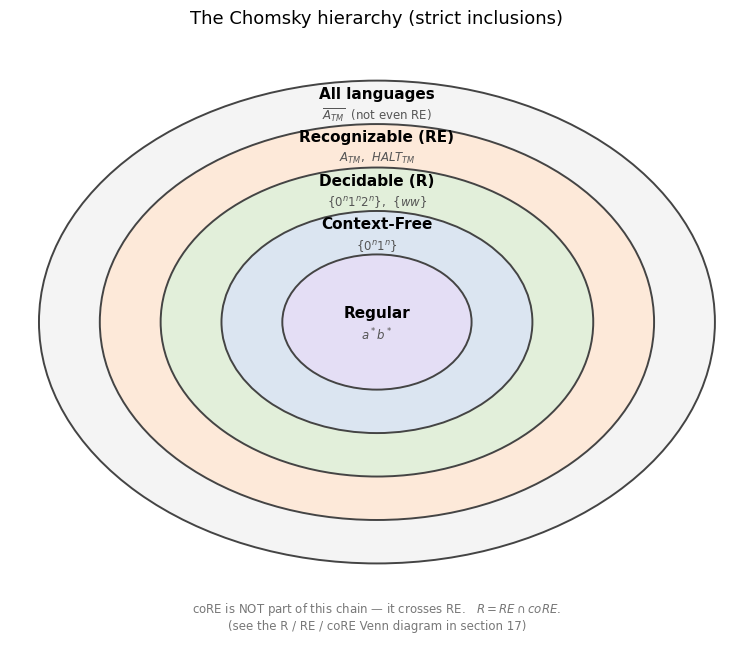

In [2]:
# The Chomsky hierarchy as concentric classes (strict inclusions).
fig, ax = plt.subplots(figsize=(8.0,6.8)); ax.set_aspect('equal'); ax.axis('off')
# (height, label, example, color) -- outermost first; width = 1.4*height
bands = [
    (10.0, "All languages",     r"$\overline{A_{TM}}$  (not even RE)", "#f4f4f4"),
    ( 8.2, "Recognizable (RE)", r"$A_{TM}$,  $HALT_{TM}$",             "#fde9d9"),
    ( 6.4, "Decidable (R)",     r"$\{0^n1^n2^n\}$,  $\{ww\}$",          "#e2efda"),
    ( 4.6, "Context-Free",      r"$\{0^n1^n\}$",                        "#dbe5f1"),
    ( 2.8, "Regular",           r"$a^*b^*$",                            "#e4def5"),
]
for h,lab,ex,c in bands:                       # large -> small, so inner sit on top
    ax.add_patch(Ellipse((0,0), h*1.4, h, facecolor=c, edgecolor="#444", lw=1.4))
tops = [h/2 for h,_,_,_ in bands]
for i,(h,lab,ex,c) in enumerate(bands):
    inner_top = tops[i+1] if i+1 < len(bands) else -h/2   # innermost: label its centre
    mid = (tops[i] + inner_top)/2
    ax.text(0, mid+0.17, lab, ha="center", va="center", fontsize=11, fontweight="bold")
    ax.text(0, mid-0.27, ex,  ha="center", va="center", fontsize=8.5, color="#555")
ax.text(0, -6.1, "coRE is NOT part of this chain — it crosses RE.   "
        r"$R = RE \cap coRE$." + "\n(see the R / RE / coRE Venn diagram in section 17)",
        ha="center", va="center", fontsize=8.5, color="#777")
ax.set_xlim(-7.6,7.6); ax.set_ylim(-7.0,6.0)
ax.set_title("The Chomsky hierarchy (strict inclusions)", fontsize=13)
plt.tight_layout(); plt.show()


<div dir="rtl">

---
# 0 · רקע מתמטי

**אלפבית** $\Sigma$ — קבוצה סופית ולא ריקה של סימנים (למשל $\{0,1\}$).

**מילה (string)** — סדרה סופית של סימנים מ-$\Sigma$. אורך $|w|$. **המילה הריקה** $\varepsilon$ מקיימת $|\varepsilon|=0$.

**$\Sigma^*$** — קבוצת *כל* המילים מעל $\Sigma$ (כולל $\varepsilon$). $\Sigma^+ = \Sigma^* \setminus \{\varepsilon\}$. שימו לב ש-$\Sigma^*$ היא **בת-מנייה אינסופית**.

**שפה** — תת-קבוצה כלשהי $L \subseteq \Sigma^*$. יש **אינסוף לא בן-מנייה** של שפות ($|\mathcal{P}(\Sigma^*)| = 2^{\aleph_0}$) אבל רק **כמות בת-מנייה** של מכונות טיורינג/תוכניות — פער המנייה הזה הוא *הסיבה* לכך שחייבות להתקיים שפות לא כריעות.

### פעולות על שפות
| פעולה | הגדרה |
|---|---|
| איחוד | $A \cup B$ |
| חיתוך | $A \cap B$ |
| משלים | $\overline{A} = \Sigma^* \setminus A$ |
| שרשור | $A\cdot B = \{xy \mid x\in A,\ y\in B\}$ |
| חזקה | $A^k = A \cdot A \cdots A$ ($k$ פעמים), $A^0=\{\varepsilon\}$ |
| כוכב קלייני | $A^* = \bigcup_{k\ge 0} A^k$ (שימו לב ש-$\varepsilon \in A^*$ תמיד) |
| היפוך | $A^R = \{w^R \mid w \in A\}$ |

⚠️ **מלכודת נפוצה:** $\varnothing^*=\{\varepsilon\}$, ו-$\varnothing \cdot A=\varnothing$ (שרשור עם *השפה* הריקה הורג הכול; שרשור עם $\{\varepsilon\}$ הוא איבר הזהות).

</div>

<div dir="rtl">

---
# חלק I — שפות רגולריות

שפה היא **רגולרית** אם *אחד* מהדברים השקולים הבאים מתקיים (השקילות בת ארבעת הדרכים הזו היא עמוד השדרה של חלק I):

$$\boxed{\text{DFA} \iff \text{NFA} \iff \text{ביטוי רגולרי} \iff \text{דקדוק רגולרי}}$$

אנו מגדירים **רגולרית = מזוהה על ידי אוטומט סופי**, ואז מוכיחים שכל פורמליזם אחר לוכד בדיוק את אותה מחלקה.

</div>

<div dir="rtl">

## 1 · אוטומט סופי דטרמיניסטי (DFA)

**DFA** הוא חמישייה $A = (Q, \Sigma, \delta, q_s, F)$:
- $Q$ — קבוצה סופית של מצבים
- $\Sigma$ — אלפבית
- $\delta : Q \times \Sigma \to Q$ — פונקציית המעברים (**מלאה** ו**דטרמיניסטית**: בדיוק מהלך אחד לכל (מצב, סימן))
- $q_s \in Q$ — מצב התחלתי
- $F \subseteq Q$ — מצבים מקבלים

**מעבר מורחב** $\hat\delta(q,w)$: היכן מסתיימים אחרי קריאת כל $w$ החל מ-$q$. מוגדר ב-$\hat\delta(q,\varepsilon)=q$ ו-$\hat\delta(q,w\sigma)=\delta(\hat\delta(q,w),\sigma)$.

**קבלה:** $A$ מקבל את $w$ אם"ם $\hat\delta(q_s, w) \in F$. **השפה** היא $L(A) = \{w \mid A \text{ accepts } w\}$.

> אינטואיציה: DFA הוא מכונה ש"קוראת פעם אחת, משמאל לימין, עם זיכרון סופי". הזיכרון היחיד שלה הוא *באיזה מצב היא נמצאת* — ולכן היא יכולה לזכור רק מספר סופי של דברים שונים על הרישא שנקראה עד כה.

</div>

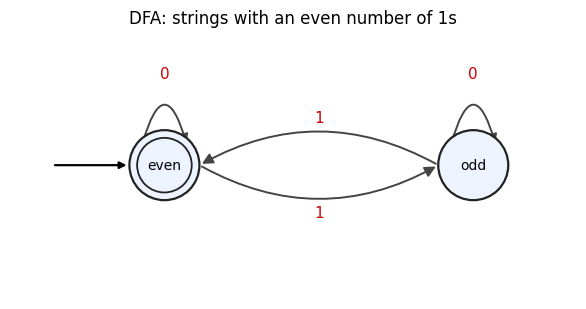

In [3]:
# State diagram of the DFA below: even number of 1s.
draw_automaton(
    pos={"even":(0,0), "odd":(3,0)},
    edges=[("even","even","0"), ("odd","odd","0"),
           ("even","odd","1"), ("odd","even","1")],
    start="even", accepting={"even"},
    title="DFA: strings with an even number of 1s", figsize=(7,3.2))


In [4]:
# A tiny DFA simulator. Example: strings over {0,1} with an even number of 1s.
def run_dfa(dfa, w):
    Q, Sigma, delta, q0, F = dfa
    q = q0
    for ch in w:
        q = delta[(q, ch)]      # total transition function
    return q in F

even_ones = (
    {"even", "odd"},                 # Q
    {"0", "1"},                       # Sigma
    {("even","0"):"even", ("even","1"):"odd",
     ("odd","0"):"odd",  ("odd","1"):"even"},  # delta
    "even",                           # start
    {"even"},                         # accepting
)

for w in ["", "0", "11", "101", "1110", "111"]:
    print(f"{w!r:7} -> {'ACCEPT' if run_dfa(even_ones, w) else 'reject'}")


''      -> ACCEPT
'0'     -> ACCEPT
'11'    -> ACCEPT
'101'   -> ACCEPT
'1110'  -> reject
'111'   -> reject


<div dir="rtl">

## 2 · אוטומט סופי אי-דטרמיניסטי (NFA)

**NFA** הוא $B = (Q, \Sigma, \delta, q_s, F)$ שבו פונקציית המעברים היא

$$\delta : Q \times \Sigma_\varepsilon \to \mathcal{P}(Q), \qquad \Sigma_\varepsilon = \Sigma \cup \{\varepsilon\}.$$

הבדלים מ-DFA:
- ייתכנו **0, 1, או הרבה** מהלכים לכל (מצב, סימן) — הפלט הוא *קבוצה* של מצבים.
- ייתכנו **מהלכי-$\varepsilon$** (מעבר מצב בלי לקרוא קלט).

**קבלה:** $B$ מקבל את $w$ אם"ם **קיים** מסלול חישוב המסתיים במצב מקבל. (אי-דטרמיניזם = "קיים ענף מקבל".)

**סגור-$\varepsilon$** $E(R)$ = כל המצבים הניתנים להגעה מהקבוצה $R$ באמצעות מהלכי-$\varepsilon$ בלבד (כולל $R$ עצמה).

### משפט (בניית קבוצת החזקה / subset construction): NFA $\equiv$ DFA
לכל NFA יש DFA שקול, ולכן NFA-ים מזהים בדיוק את השפות הרגולריות. בהינתן NFA $N=(Q_N,\Sigma,\delta_N,q_s,F_N)$ בונים DFA $D$:
- $Q_D = \mathcal{P}(Q_N)$ — **המצבים הם קבוצות של מצבי NFA**
- $\delta_D(R,\sigma) = \bigcup_{r\in R} E(\delta_N(r,\sigma))$
- $q_{s_D} = E(\{q_s\})$
- $F_D = \{R \subseteq Q_N \mid R \cap F_N \neq \varnothing\}$

⚠️ **התפוצצות:** NFA עם $n$ מצבים יכול להפוך ל-DFA עם $2^n$ מצבים — ולעיתים זה בלתי נמנע.

> **למה להשתמש ב-NFA?** הם הופכים בניות רבות לטריוויאליות (ביטוי רגולרי→אוטומט, איחוד, שרשור, כוכב) כי אפשר "לנחש". הם אף פעם לא מזהים משהו חדש, אבל הרבה יותר קל *לתכנן* אותם.

</div>

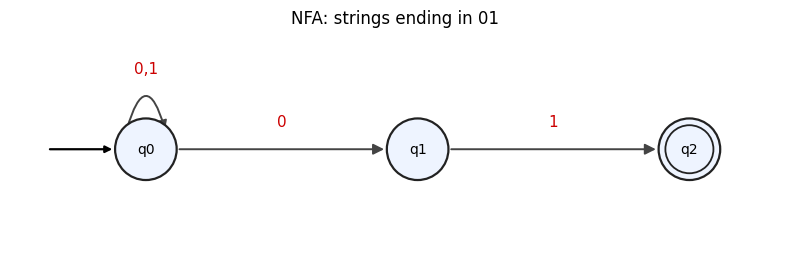

In [5]:
# State diagram of the NFA below: strings ending in "01".
# Note the two moves on "0" from q0 (to q0 AND q1) -- that is the nondeterminism.
draw_automaton(
    pos={"q0":(0,0), "q1":(3,0), "q2":(6,0)},
    edges=[("q0","q0","0,1"), ("q0","q1","0"), ("q1","q2","1")],
    start="q0", accepting={"q2"},
    title="NFA: strings ending in 01", figsize=(8,3.0))


In [6]:
# NFA simulator via subset tracking. Example: {w | w ends in "01"}.
def run_nfa(nfa, w):
    Q, Sigma, delta, q0, F = nfa
    def eclose(states):
        stack, seen = list(states), set(states)
        while stack:
            s = stack.pop()
            for t in delta.get((s, ""), set()):
                if t not in seen:
                    seen.add(t); stack.append(t)
        return seen
    cur = eclose({q0})
    for ch in w:
        nxt = set()
        for s in cur:
            nxt |= delta.get((s, ch), set())
        cur = eclose(nxt)
    return bool(cur & F)

ends_01 = (
    {"q0","q1","q2"}, {"0","1"},
    {("q0","0"):{"q0","q1"}, ("q0","1"):{"q0"},   # stay in q0; guess the "01" start
     ("q1","1"):{"q2"}},                           # q1 --1--> q2 (accept)
    "q0", {"q2"},
)
for w in ["01","001","0","10","1101","11"]:
    print(f"{w!r:6} -> {'ACCEPT' if run_nfa(ends_01, w) else 'reject'}")


'01'   -> ACCEPT
'001'  -> ACCEPT
'0'    -> reject
'10'   -> reject
'1101' -> ACCEPT
'11'   -> reject


<div dir="rtl">

## 3 · ביטויים רגולריים (regex)

נבנים אינדוקטיבית. ה**אטומים** הם $\varnothing$, $\varepsilon$, וכל $\sigma \in \Sigma$. אם $R_1,R_2$ ביטויים רגולריים, אז גם $(R_1 + R_2)$ (איחוד), $(R_1 R_2)$ (שרשור), $(R_1^*)$ (כוכב). קדימויות: $* > \cdot > +$.

**משפט (קלייני): ביטוי רגולרי $\equiv$ אוטומט סופי.** שפה היא רגולרית אם"ם ביטוי רגולרי כלשהו מתאר אותה.

### regex → NFA (בניית תומפסון)
מחליפים רקורסיבית כל אופרטור בגאדג'ט קטן של $\varepsilon$-NFA:
- **$r + s$** — הסתעפות לשני תתי-ה-NFA במהלכי-$\varepsilon$.
- **$rs$** — חיווט המצב המקבל של $r$ למצב ההתחלתי של $s$.
- **$r^*$** — הוספת לולאת-$\varepsilon$ חזרה ומעקף-$\varepsilon$ עבור $\varepsilon$.

ממשיכים עד שכל קשת מתויגת בסימן יחיד מ-$\Sigma_\varepsilon$.

### NFA → regex (דרך GNFA — סילוק מצבים)
**GNFA** מתייג קשתות ב*ביטויים רגולריים*. תהליך:
1. הוסיפו מצב התחלתי חדש $s$ עם $\varepsilon$ למצב ההתחלתי הישן (קשתות יוצאות בלבד), ומצב מקבל יחיד חדש $f$ עם $\varepsilon$ מכל מצב מקבל ישן (קשתות נכנסות בלבד).
2. ודאו שיש בדיוק קשת אחת בין כל זוג סדור (השתמשו ב-$+$ למיזוג, תייגו קשתות חסרות ב-$\varnothing$).
3. **סלקו** מצבים פנימיים אחד-אחד. בהסרת $k$, לכל זוג נותר $(i,j)$ עדכנו:
$$\text{new}(i,j) = \text{old}(i,j) + \text{old}(i,k)\,\big(\text{old}(k,k)\big)^*\,\text{old}(k,j).$$
4. כשנותרו רק $s,f$, התווית על הקשת $s\to f$ היא הביטוי הרגולרי.

תזכורת: $\varnothing^* = \{\varepsilon\}$.

</div>

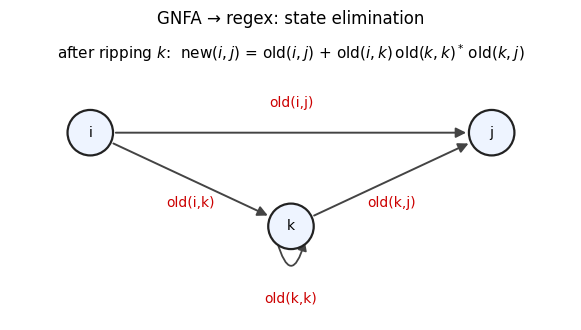

In [7]:
# GNFA state-elimination: removing state k rewires every i -> j path through k.
fig, ax = plt.subplots(figsize=(8,3.4)); ax.set_aspect('equal'); ax.axis('off')
P = {"i":(0,1.4), "k":(3,0), "j":(6,1.4)}
for st,(x,y) in P.items():
    ax.add_patch(Circle((x,y),0.34,facecolor="#eef4ff",edgecolor="#222",lw=1.6,zorder=3))
    ax.text(x,y,st,ha="center",va="center",zorder=4)
def edge(a,b,lab,rad=0.0,dy=0.3):
    x1,y1=P[a]; x2,y2=P[b]; dx,dyy=x2-x1,y2-y1; d=(dx*dx+dyy*dyy)**.5; ux,uy=dx/d,dyy/d
    ax.add_patch(FancyArrowPatch((x1+ux*0.34,y1+uy*0.34),(x2-ux*0.34,y2-uy*0.34),
        connectionstyle=f"arc3,rad={rad}",arrowstyle="-|>",mutation_scale=15,lw=1.4,color="#444"))
    ax.text((x1+x2)/2,(y1+y2)/2+dy,lab,ha="center",va="center",color="#c00",fontsize=10)
edge("i","j","old(i,j)",rad=0.0,dy=0.45)
edge("i","k","old(i,k)",dy=-0.35)
edge("k","j","old(k,j)",dy=-0.35)
# self-loop on k, bulging downward (k sits at the bottom of the figure)
ax.add_patch(FancyArrowPatch((3-0.22,-0.34*0.55),(3+0.22,-0.34*0.55),
    connectionstyle="arc3,rad=1.8", arrowstyle="-|>",
    mutation_scale=13,lw=1.3,color="#444"))
ax.text(3,-1.15,"old(k,k)",ha="center",color="#c00",fontsize=10)
ax.text(3,2.5,r"after ripping $k$:  new$(i,j)$ = old$(i,j)$ + old$(i,k)\,$old$(k,k)^*\,$old$(k,j)$",
        ha="center",fontsize=11)
ax.set_xlim(-1.2,7.2); ax.set_ylim(-1.4,2.9)
ax.set_title("GNFA → regex: state elimination", fontsize=12)
plt.tight_layout(); plt.show()


<div dir="rtl">

## 4 · דקדוקים רגולריים (RG)

ב**דקדוק רגולרי** כל כלל הוא מהצורה
$$A \to w \quad\text{or}\quad A \to wB \qquad (A,B\in V,\ w\in\Sigma^*).$$
(לינארי-ימני.) אלו יוצרים **בדיוק** את השפות הרגולריות.

**דקדוק רגולרי פשוט (SRG)** מצמצם עוד יותר: $A\to\sigma B$ עם $\sigma\in\Sigma_\varepsilon$, ו-$A\to\varepsilon$. SRG-ים מתאימים ישירות ל-NFA-ים.

**NFA → RG:** משתנה אחד לכל מצב; המעבר $\delta(A,\sigma)=B$ הופך ל-$A\to\sigma B$; מהלך-$\varepsilon$ הופך ל-$A\to B$; מצב מקבל $q$ מקבל $A\to\varepsilon$.

**RG → NFA:** ממירים ל-SRG, ואז מצבים = משתנים, וכללים $A\to\sigma B$ הופכים למעברים, $A\to\sigma$ הופך למעבר אל מצב מקבל חדש.

> זה סוגר את הלולאה בת ארבעת הדרכים: **DFA ↔ NFA ↔ ביטוי רגולרי ↔ דקדוק רגולרי** — כולם מתארים את השפות הרגולריות.

</div>

<div dir="rtl">

## 5 · תכונות סגירוּת של שפות רגולריות

השפות הרגולריות סגורות תחת **כל** פעולה סטנדרטית:

| פעולה | רעיון הבנייה |
|---|---|
| איחוד $A\cup B$ | אוטומט מכפלה (מקבל אם *אחד מהם*) או NFA עם שני ענפים |
| חיתוך $A\cap B$ | **אוטומט מכפלה** $Q_A\times Q_B$, מקבל אם *שניהם* ב-$F$ |
| משלים $\overline A$ | DFA: החלפת $F \leftrightarrow Q\setminus F$ (⚠️ חייבים **DFA מלא** קודם, לא NFA!) |
| שרשור $A\cdot B$ | קישור-$\varepsilon$ ממצבי הקבלה של $A$ למצב ההתחלתי של $B$ |
| כוכב $A^*$ | מצב התחלתי חדש (מקבל, עבור $\varepsilon$) + לולאת-$\varepsilon$ חזרה |
| היפוך $A^R$ | היפוך כל הקשתות, החלפת מצב התחלתי/מקבל (דרך NFA) |
| הומומורפיזם / הצבה | החלפת כל סימן בשפה רגולרית |

### בניית המכפלה (cross-product) — סוס העבודה
עבור $A=(Q_A,\Sigma,\delta_A,s_A,F_A)$ ו-$B=(Q_B,\Sigma,\delta_B,s_B,F_B)$ בונים
$$Q=Q_A\times Q_B,\quad \delta((p,q),\sigma)=(\delta_A(p,\sigma),\delta_B(q,\sigma)),\quad s=(s_A,s_B).$$
בוחרים את $F$ לפי הפעולה: **חיתוך** $F_A\times F_B$; **איחוד** $\{(p,q): p\in F_A \text{ or } q\in F_B\}$; **הפרש** $F_A\times(Q_B\setminus F_B)$.

> **טקטיקת מבחן:** תכונות סגירוּת נותנות הוכחות *אי-רגולריות* נקיות בדרך השלילה. למשל, אם $L\cap(\text{regular})$ הייתה רגולרית אבל שווה לשפה לא-רגולרית ידועה — סתירה.

</div>

<div dir="rtl">

## 6 · מייהיל–נרוד, שקילות מצבים, ומינימיזציה

### מילים מפרידות ומצבים שקולים
מילה $w$ **מפרידה** בין מצבים $p,q$ אם בדיוק אחד מ-$\hat\delta(p,w),\hat\delta(q,w)$ מקבל.
- $p \equiv_k q$ ("שקולים-$k$"): **אין** מילה באורך $\le k$ שמפרידה ביניהם.
- $p \equiv q$ (שקולים): $p\equiv_k q$ לכל $k\ge 0$.

### מציאת מחלקות שקילות (DFA בלבד) — מילוי טבלה / עידון חלוקה
1. מחקו מצבים לא ישיגים.
2. $E_0 = \{F,\ Q\setminus F\}$ (מקבלים מול לא-מקבלים).
3. עדנו: פצלו מחלקה אם לשני איברים $p,q$ מתקיים ש-$\delta(p,\sigma)$ ו-$\delta(q,\sigma)$ במחלקות *שונות* של $E_{k-1}$ עבור $\sigma$ כלשהו.
4. עצרו כש-$E_k = E_{k-1}$.

**טענה:** DFA-ים $A,B$ שקולים ($L(A)=L(B)$) אם"ם $q_{s_A}\equiv q_{s_B}$ (מריצים את האלגוריתם על האיחוד הזר).

### מינימיזציה
מריצים את האלגוריתם, ואז יוצרים **מצב אחד לכל מחלקת שקילות**. התוצאה היא ה-DFA המינימלי **היחיד** (עד כדי שינוי שמות) עבור $L$.

> **משפט מייהיל–נרוד (הסיבה העמוקה):** $L$ רגולרית **אם"ם** ליחס $x \sim_L y$ ("$xz\in L \Leftrightarrow yz\in L$ לכל $z$") יש *מספר סופי* של מחלקות שקילות, ומספר זה שווה לגודל ה-DFA המינימלי. אינסוף מחלקות ⇒ לא רגולרית (חלופה ללמת הניפוח).

</div>

In [8]:
# DFA minimization by partition refinement (Hopcroft-style, simple version).
def minimize(dfa):
    Q, Sigma, delta, q0, F = dfa
    # (assume all states reachable for brevity)
    P = [set(F), set(Q) - set(F)]
    P = [c for c in P if c]
    def class_of(state, part):
        for i, c in enumerate(part):
            if state in c: return i
    changed = True
    while changed:
        changed = False
        newP = []
        for c in P:
            buckets = {}
            for s in c:
                sig = tuple(class_of(delta[(s, a)], P) for a in sorted(Sigma))
                buckets.setdefault(sig, set()).add(s)
            newP.extend(buckets.values())
            if len(buckets) > 1: changed = True
        P = newP
    return P

# DFA with a redundant state: accepts strings ending in 0. q1 and q3 are equivalent.
dfa = (
    {"q0","q1","q2","q3"}, {"0","1"},
    {("q0","0"):"q1",("q0","1"):"q2",
     ("q1","0"):"q1",("q1","1"):"q2",
     ("q2","0"):"q3",("q2","1"):"q2",
     ("q3","0"):"q1",("q3","1"):"q2"},
    "q0", {"q1","q3"},
)
print("Equivalence classes (merged states):")
for c in minimize(dfa):
    print("  ", sorted(c))


Equivalence classes (merged states):
   ['q1', 'q3']
   ['q0', 'q2']


<div dir="rtl">

## 7 · למת הניפוח לשפות רגולריות

> אם $L$ רגולרית, קיים **אורך ניפוח** $n\in\mathbb{N}$ כך שכל $w\in L$ עם $|w|\ge n$ ניתנת לפיצול $w = xyz$ כך ש:
> 1. $|y| > 0$  (החלק המנופח אינו ריק)
> 2. $|xy| \le n$  (הוא מופיע בתוך $n$ הסימנים הראשונים)
> 3. $xy^iz \in L$ לכל $i \ge 0$.

*הערת אורך:* אם $|y|=t$ אז $|xy^iz| = |w| + (i-1)t$.

**למה זה נכון:** קריאת $n$ סימנים מבקרת ב-$n+1$ מצבים; לפי עקרון שובך היונים שניים מתלכדים, ונותנים לולאה $y$ שאפשר לחזור עליה או למחוק.

### איך מוכיחים ששפה **אינה** רגולרית (משחק היריב)
משחקים *נגד* הלמה. סדר הכמתים הוא העיקר:
1. נניח ש-$L$ רגולרית ⇒ נקבל אורך ניפוח $n$ כלשהו (אתם **לא** בוחרים את $n$).
2. **אתם בוחרים** מילה מסוימת $w\in L$ עם $|w|\ge n$ (בחוכמה, בד"כ כתלות ב-$n$).
3. עבור **כל** פיצול $w=xyz$ המקיים $|y|>0,\ |xy|\le n$ (צריך לטפל בכולם — אבל תנאי 2 בד"כ מצמצם את $y$ לאזור ידוע!),
4. **אתם בוחרים** $i$ (לרוב $i=0$ או $i=2$) כך ש-$xy^iz \notin L$ — סתירה.

**שפות לא-רגולריות קלאסיות:** $\{0^n1^n\}$, $\{ww \mid w\in\Sigma^*\}$, $\{0^{n^2}\}$, $\{0^p \mid p \text{ prime}\}$, $\{w : \#_0(w)=\#_1(w)\}$, סוגריים מאוזנים.

⚠️ למת הניפוח היא תנאי **הכרחי, לא מספיק**: יש שפות לא-רגולריות ש*כן* ניתנות לניפוח. לכן היא רק **מפריכה** רגולריות. (מייהיל–נרוד הוא האפיון השקול.)

</div>

In [9]:
# Pumping-lemma "experiment": show 0^n 1^n breaks when you pump y inside the 0s.
def in_L(w):                       # L = { 0^k 1^k }
    return w == "0"*(len(w)//2) + "1"*(len(w)//2) and w.count("0") == w.count("1")

n = 4
w = "0"*n + "1"*n                  # w in L, |w| >= n
print("w =", w, "in L?", in_L(w))
# Any valid split has xy within first n symbols => y is all 0s. Pump i=2:
x, y, z = "00", "0", w[3:]         # |y|>0, |xy|<=n
for i in [0, 2]:
    pumped = x + y*i + z
    print(f"i={i}: {pumped!r:12} in L? {in_L(pumped)}")   # both leave L


w = 00001111 in L? True
i=0: '0001111'    in L? False
i=2: '000001111'  in L? False


<div dir="rtl">

---
# חלק II — שפות חסרות הקשר

שפה היא **חסרת הקשר** אם *אחד* מהדברים הבאים מתקיים:

$$\boxed{\text{נוצרת ע"י CFG} \iff \text{מזוהה ע"י PDA}}$$

שפות חסרות הקשר מרחיבות ממש את הרגולריות: הן מוסיפות **מחסנית** אחת של זיכרון (לא חסום), שזה בדיוק מה שדרוש כדי להתאים מבנה מקונן/רקורסיבי כמו $0^n1^n$ או סוגריים מאוזנים.

</div>

<div dir="rtl">

## 8 · דקדוקים חסרי הקשר (CFG)

**CFG** הוא רביעייה $G=(V,\Sigma,S,R)$:
- $V$ — משתנים (לא-טרמינלים)
- $\Sigma$ — טרמינלים, $V\cap\Sigma=\varnothing$
- $S\in V$ — משתנה התחלתי
- $R$ — כללים $A\to\alpha$ כאשר $A\in V$, $\alpha\in(V\cup\Sigma)^*$

**גזירה:** $\alpha A\beta \Rightarrow \alpha\gamma\beta$ אם $A\to\gamma\in R$. $\overset{*}{\Rightarrow}$ הוא אפס או יותר צעדים. **השפה** היא $L(G)=\{w\in\Sigma^* \mid S\overset{*}{\Rightarrow}w\}$.

- **גזירה שמאלית/ימנית** — הרחבה תמיד של המשתנה השמאלי/ימני ביותר.
- **עץ גזירה** — שורש $S$, העלים מאייתים את $w$; הצמתים הפנימיים הם יישומי כללים.
- **דקדוק רב-משמעי** — למילה כלשהי יש $\ge 2$ עצי גזירה שונים (שקול ל-$\ge 2$ גזירות שמאליות). שפה היא **רב-משמעית מהותית** אם *כל* CFG עבורה רב-משמעי (למשל $\{a^ib^jc^k : i=j \text{ or } j=k\}$).

**דוגמה:** $S \to 0S1 \mid \varepsilon$ יוצר את $\{0^n1^n \mid n\ge 0\}$ — לא רגולרית, אבל חסרת הקשר.

</div>

In [10]:
# Brute-force CFG recognizer (bounded derivation length) to *play* with grammars.
def derivations(rules, start, target, max_steps=12):
    """rules: dict var -> list of RHS strings (terminals lowercase/digits, vars uppercase)."""
    from collections import deque
    seen, q = {start}, deque([(start, 0)])
    while q:
        form, d = q.popleft()
        if form == target: return True
        if d >= max_steps: continue
        for i, ch in enumerate(form):
            if ch in rules:
                for rhs in rules[ch]:
                    nf = form[:i] + rhs + form[i+1:]
                    # prune sentential forms that already have too many terminals
                    if len(nf) <= len(target) + 4 and nf not in seen:
                        seen.add(nf); q.append((nf, d+1))
    return False

# S -> 0S1 | e   (e = epsilon, represented as "")
rules = {"S": ["0S1", ""]}
for w in ["", "01", "0011", "000111", "001", "0101"]:
    print(f"{w!r:9} in L(G)? {derivations(rules, 'S', w)}")


''        in L(G)? True
'01'      in L(G)? True
'0011'    in L(G)? True
'000111'  in L(G)? True
'001'     in L(G)? False
'0101'    in L(G)? False


<div dir="rtl">

## 9 · פישוט דקדוקים וצורה נורמלית של חומסקי (CNF)

דקדוק **מפושט** הוא דקדוק ללא כללי-$\varepsilon$ (פרט אולי ל-$S\to\varepsilon$) וללא **כללי יחידה** ($A\to B$).

**הסרת כללי-$\varepsilon$:** מצאו $A\to\varepsilon$ ($A\ne S$), מחקו אותו, ולכל כלל המכיל $A$ באגף ימין הוסיפו עותקים עם מחיקת $A$ (לכל *מופע* ולכל *תת-קבוצה* של מופעים). אם $\varepsilon\in L$, טפלו בכך דרך משתנה התחלתי חדש $S'\to S\mid\varepsilon$.

**הסרת כללי יחידה:** מצאו $A\to B$, מחקו אותו, והוסיפו $A\to\alpha$ לכל כלל $B\to\alpha$.

### צורה נורמלית של חומסקי
כל כלל הוא מאחד מהבאים:
$$A\to BC \quad(B,C\ne S),\qquad A\to\sigma,\qquad (\text{and } S\to\varepsilon \text{ only if } \varepsilon\in L).$$

**CFG → CNF (אלגוריתם):**
1. **START:** הוסיפו $S'\to S$ (משתנה התחלתי חדש).
2. **DEL:** הסירו כללי-$\varepsilon$.
3. **UNIT:** הסירו כללי יחידה.
4. **TERM/BIN:** החליפו טרמינל $\sigma$ באגף ימין ארוך במשתנה חדש עם $A_\sigma\to\sigma$; פרקו $A\to B_1B_2\cdots B_k$ ($k>2$) לשרשרת $A\to B_1C_1,\ C_1\to B_2\cdots B_k,\dots$

**למה CNF חשוב:**
- גזירת CNF של $w$ ($|w|=m\ge 1$) משתמשת ב**בדיוק $2m-1$** יישומי כללים — הגזירות חסומות ⇒ שייכות היא **כריעה**.
- זהו פורמט הקלט לאלגוריתם הניתוח **CYK** (בדיקת שייכות ב-$O(m^3)$).
- זוהי ההכנה ל**למת הניפוח לשפות חסרות הקשר** (הסתעפות חסומה ⇒ עצי גזירה גבוהים חוזרים על משתנה).

</div>

<div dir="rtl">

## 10 · אוטומטי מחסנית (PDA)

**PDA** הוא שישייה $A=(Q,\Sigma,\Gamma,\delta,q_s,F)$:
- $\Gamma$ — **אלפבית המחסנית**
- $\delta : Q\times\Sigma_\varepsilon\times\Gamma_\varepsilon \to \mathcal{P}(Q\times\Gamma_\varepsilon)$

מהלך קורא סימן קלט (אופציונלי), שולף סימן מחסנית (אופציונלי), ודוחף סימן מחסנית (אופציונלי), ועובר למצב חדש. PDA-ים הם **אי-דטרמיניסטיים** (DPDA חלשים ממש — בניגוד לאוטומטים סופיים!).

**קבלה** (בקורס זה): לפי **מצב סופי** — קיים ענף שקורא את כל הקלט ומסתיים ב-$F$.

**PDA מפושט** (בשימוש בהוכחת PDA→CFG) — שלושה תנאים:
1. בדיוק מצב מקבל אחד $q_f$;
2. המחסנית **ריקה** בעת הקבלה;
3. כל מהלך הוא **או** דחיפה **או** שליפה, לעולם לא שניהם, לעולם לא אף אחד.

### משפט: PDA $\equiv$ CFG
שפה היא חסרת הקשר אם"ם PDA כלשהו מזהה אותה.

</div>

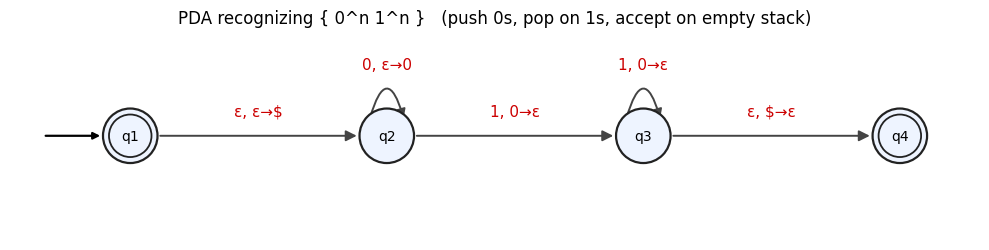

In [11]:
# PDA for { 0^n 1^n } (Sipser-style). Label format:  read, pop -> push   ($ = stack bottom).
draw_automaton(
    pos={"q1":(0,0), "q2":(3.2,0), "q3":(6.4,0), "q4":(9.6,0)},
    edges=[("q1","q2", u"ε, ε→$"),
           ("q2","q2", u"0, ε→0"),
           ("q2","q3", u"1, 0→ε"),
           ("q3","q3", u"1, 0→ε"),
           ("q3","q4", u"ε, $→ε")],
    start="q1", accepting={"q1","q4"},
    title="PDA recognizing { 0^n 1^n }   (push 0s, pop on 1s, accept on empty stack)",
    figsize=(10,3.0))


<div dir="rtl">

## 11 · המרות CFG ↔ PDA

### CFG → PDA (3 מצבים)
רעיון: מחזיקים את התבנית הנוכחית במחסנית; מרחיבים משתנים, מתאימים טרמינלים.
- $q_{start} \xrightarrow{\ \varepsilon,\varepsilon\to S\$\ } q_{loop}$ (דחיפת משתנה התחלתי וסמן תחתית).
- ב-$q_{loop}$: לכל כלל $A\to\alpha_1\cdots\alpha_k$, מהלך $(\varepsilon, A\to \alpha_1\cdots\alpha_k)$ (שליפת $A$, דחיפת אגף ימין); לכל טרמינל $a$, מהלך $(a, a\to\varepsilon)$ (התאמה ושליפה).
- $q_{loop}\xrightarrow{\ \varepsilon,\$\to\varepsilon\ } q_{accept}$.

### PDA → CFG
מפשטים את ה-PDA, ואז לכל זוג $p,q$ מכניסים משתנה $A_{p,q}$ שיוצר בדיוק את המילים שמעבירות את ה-PDA מ-$p$ (מחסנית ריקה) ל-$q$ (מחסנית ריקה). אז $S=A_{q_s,q_f}$ והכללים הם:
- $A_{p,q}\to A_{p,r}A_{r,q}$  (פיצול החישוב),
- $A_{p,p}\to\varepsilon$,
- $A_{p,q}\to \sigma' A_{r,s}\sigma''$ כאשר דחיפת $\gamma$ ב-$p$ (מעבר ל-$r$) מותאמת לשליפת אותו $\gamma$ ב-$s$ (מעבר ל-$q$).

</div>

<div dir="rtl">

## 12 · למת הניפוח לשפות חסרות הקשר

> אם $L$ חסרת הקשר, קיים **אורך ניפוח** $p$ כך שכל $w\in L$ עם $|w|\ge p$ ניתנת לפיצול $w=uvxyz$ כך ש:
> 1. $|vy|>0$  (לפחות אחד מ-$v,y$ אינו ריק)
> 2. $|vxy|\le p$  (האמצע המנופח קצר)
> 3. $uv^ixy^iz\in L$ לכל $i\ge 0$.

*הערת אורך:* $|uv^ixy^iz| = |w| + (i-1)(|v|+|y|)$.

**למה:** בעץ גזירה ב-CNF, מילה ארוכה מאלצת מסלול שורש-עלה ארוך מספיק כך שמשתנה $R$ כלשהו חוזר; שני המופעים של $R$ תוחמים את $v$ (משמאל) ואת $y$ (מימין), שאפשר לנפח יחד.

### הפרכת חוסר-הקשר — אותו משחק יריב, שני חלקים מנופחים
1. נניח חסרת הקשר ⇒ נקבל $p$.
2. **אתם** בוחרים $w\in L$, $|w|\ge p$.
3. עבור **כל** פיצול $uvxyz$ עם $|vy|>0$, $|vxy|\le p$,
4. **אתם** בוחרים $i$ כך ש-$uv^ixy^iz\notin L$.

התנאי $|vxy|\le p$ הוא חבר שלכם: $vxy$ הוא חלון קצר, כך ש-$v,y$ לא יכולים לפרוס את כל שלושת ה"בלוקים" של מילה כמו $0^p1^p2^p$ — ניפוח מערער את האיזון.

**שפות לא-חסרות-הקשר קלאסיות:** $\{0^n1^n2^n\}$, $\{ww \mid w\in\Sigma^*\}$, $\{a^ib^jc^k : i\le j\le k\}$, $\{0^{n^2}\}$, $\{a^nb^nc^n\}$.

⚠️ כמו במקרה הרגולרי: הכרחי, לא מספיק.

</div>

<div dir="rtl">

## 13 · תכונות סגירוּת של שפות חסרות הקשר והצבה

**שפות חסרות הקשר סגורות תחת:** איחוד, שרשור, כוכב קלייני, היפוך, **הצבה / הומומורפיזם**, ו**חיתוך עם שפה רגולרית**.

**שפות חסרות הקשר אינן סגורות תחת:** **חיתוך** או **משלים**.
- דוגמה נגדית לחיתוך: $\{a^nb^nc^m\}\cap\{a^mb^nc^n\} = \{a^nb^nc^n\}$ — כל גורם חסר הקשר, החיתוך לא.
- משלים נכשל כי $\overline{\;\cdot\;}$ + $\cup$ היו נותנים $\cap$ דרך דה-מורגן.

### הצבה (כלי מרכזי בקורס)
**הצבה** מחליפה כל סימן $\sigma\in\Sigma_1$ בשפה שלמה $L_\sigma\subseteq\Sigma_2^*$:
- על סימן: $f(\sigma)=L_\sigma$;
- על מילה: $g(\sigma_1\cdots\sigma_n)=\{w_1\cdots w_n : w_i\in f(\sigma_i)\}$;
- על שפה: $h(L)=\bigcup_{w\in L} g(w)$.

### הומומורפיזם — המקרה הפרטי של הצבה
**הומומורפיזם** ממפה כל סימן ל*מילה יחידה* (לא לשפה שלמה): פונקציה $h:\Sigma_1\to\Sigma_2^*$, המורחבת למילים ע"י $h(\sigma_1\cdots\sigma_n)=h(\sigma_1)h(\sigma_2)\cdots h(\sigma_n)$ ולשפות ע"י $h(L)=\{h(w)\mid w\in L\}$. חשבו על זה כ**"מצא-והחלף כל אות במילה קבועה."**
- דוגמה: $h(0)=ab,\ h(1)=\varepsilon$ שולח $0011 \mapsto abab$ ו-$\{0^n1^n\}\mapsto\{(ab)^n\}$.
- זוהי בדיוק הצבה שבה כל $L_\sigma=\{$מילה אחת$\}$, ולכן משפט הסגירוּת שלמטה מכסה אותה: **שפות רגולריות וחסרות הקשר סגורות תחת הומומורפיזם** (וגם תחת הומומורפיזם *הפוך* $h^{-1}(L)=\{w\mid h(w)\in L\}$).
- הצבת $h(\sigma)=\varepsilon$ עבור חלק מהסימנים היא טריק ה**מחיקה/היטל (projection)** — שימושי לטרנספורמציות בסגנון "מחק את כל ה-$a$-ים".

**משפטי סגירוּת:**
- אם $L$ רגולרית וכל $L_\sigma$ רגולרית ⇒ $h(L)$ רגולרית.
- אם $L$ חסרת הקשר וכל $L_\sigma$ חסרת הקשר ⇒ $h(L)$ חסרת הקשר.

> **טכניקה חזקה (מהרצאה 13):** כדי להוכיח ששפה מותמרת $f(L)$ רגולרית/חסרת הקשר, *בנו אותה מ-$L$ באמצעות פעולות סגירוּת* — הצבה, חיתוך עם שפה רגולרית, הומומורפיזם. דוגמה: $\mathrm{op}(L)=\{zx \mid xyz\in L\}$ רגולרית כש-$L$ כזו, על ידי כתיבת $L=\bigcup L_{q_0,p}\cdot L_{p,q}\cdot L_{q,f}$ מעל המצבים וחיבור החלקים מחדש.

</div>

<div dir="rtl">

---
# חלק III — מכונות טיורינג וחישוביות

מכונת טיורינג היא המודל שלנו ל"כל אלגוריתם שהוא".

**תזת צ'רץ'–טיורינג:** המושג האינטואיטיבי של *חישוב אפקטיבי/אלגוריתמי* מתלכד בדיוק עם *ניתן-לחישוב-טיורינג*. (תזה, לא משפט — אבל היסוד שמאפשר לנו לומר "מ"ט = אלגוריתם".)

</div>

<div dir="rtl">

## 14 · מכונות טיורינג (TM)

**מ"ט** היא שביעייה $M=(Q,\Sigma,\Gamma,\delta,q_s,q_{acc},q_{rej})$:
- $\Sigma$ — אלפבית הקלט, עם הרווח $\sqcup\notin\Sigma$
- $\Gamma$ — אלפבית הסרט, $\sqcup\in\Gamma$ ו-$\Sigma\subseteq\Gamma$
- $\delta : Q\times\Gamma \to Q\times\Gamma\times\{L,R\}$ — קריאה, כתיבה, הזזת הראש שמאלה/ימינה
- $q_{acc}\ne q_{rej}$ — מצבי עצירה

**תצורה (configuration)** $uqv$: תוכן הסרט $uv$, מצב $q$, הראש על הסימן הראשון של $v$. צעדי החישוב עוברים בין תצורות עד הגעה ל-$q_{acc}$ (קבלה) או $q_{rej}$ (דחייה), **או שהמכונה רצה לנצח**.

על קלט $w$, $M$ יכולה: **לקבל**, **לדחות**, או **להיתקע בלולאה** (לא לעצור לעולם). האפשרות השלישית היא כל הסיפור של החישוביות.

### שני מושגים של "פתרון"
- **$M$ מזהה את $L$** ($L$ היא **ניתנת לזיהוי / RE**): $M$ מקבלת בדיוק את ה-$w\in L$; על $w\notin L$ היא עשויה לדחות **או להיתקע בלולאה**.
- **$M$ מכריעה את $L$** ($L$ היא **כריעה / R**): $M$ עוצרת על **כל** קלט, מקבלת $w\in L$ ודוחה $w\notin L$. מכריע אף פעם לא נתקע בלולאה.

### חוסן (כולם מזהים את אותה מחלקה)
מ"ט רב-סרטית, מ"ט אי-דטרמיניסטית (NTM), מ"ט עם הישארות-במקום, סרט דו-כיווני, מונים (enumerators) — **כולם שקולים** למ"ט הבסיסית. מ"ט רב-סרטית מדומה ע"י סרט יחיד; NTM מדומה ע"י מ"ט דטרמיניסטית דרך חיפוש **לרוחב** בעץ החישוב (BFS, לא DFS, כדי שתמיד יימצא ענף מקבל).

**מונה (enumerator):** מ"ט שמדפיסה רשימה (אולי אינסופית) של מילים. $L$ היא **RE אם"ם מונה כלשהו מונה אותה**; $L$ היא **כריעה אם"ם מונה כלשהו מונה אותה בסדר אורך/לקסיקוגרפי (לא יורד)**.

</div>

<div dir="rtl">

## 15 · קידודים, מכונת טיורינג אוניברסלית, ומנייה

- $\langle O\rangle$ = מילה סופית ש**מקודדת** אובייקט $O$ (DFA, דקדוק, מ"ט אחרת, רביעייה...). כל דבר סופי ניתן לקידוד; "$\langle M,w\rangle$" מזין תיאור מכונה ועוד קלט למכונה אחרת.
- **מ"ט אוניברסלית $U$:** על קלט $\langle M,w\rangle$, מדמה את $M$ על $w$. $U$ מזהה את $A_{TM}$. (זהו ה"מחשב עם תוכנה שמורה" התיאורטי.)

### טיעון המנייה (קיומן של שפות לא כריעות)
- מ"ט-ים ↔ מילים סופיות ⇒ **כמות בת-מנייה** של מ"ט-ים ⇒ כמות בת-מנייה של שפות הניתנות לזיהוי.
- שפות = $\mathcal{P}(\Sigma^*)$ ⇒ **אינסוף לא בן-מנייה**.
- לכן **רוב** השפות אינן ניתנות לזיהוי בכלל. דיאגונליזציה הופכת שפה *ספציפית* כזו למפורשת.

</div>

<div dir="rtl">

## 16 · בעיות כריעות (ארגז הכלים של R)

אלו **כריעות** — בונים מ"ט שעוצרת תמיד. הן "פונקציות הספרייה" שלכם לרדוקציות:

| שפה | רעיון המכריע |
|---|---|
| $A_{DFA}=\{\langle D,w\rangle : D\text{ accepts }w\}$ | מדמים את $D$ על $w$ (סופי) |
| $A_{NFA}$, $A_{REX}$ | ממירים ל-DFA, מדמים |
| $E_{DFA}=\{\langle D\rangle : L(D)=\varnothing\}$ | ישיגוּת: האם ניתן להגיע למצב מקבל? |
| $EQ_{DFA}=\{\langle D_1,D_2\rangle : L(D_1)=L(D_2)\}$ | האם ההפרש הסימטרי $L(D_1)\triangle L(D_2)$ ריק? (משתמש ב-$E_{DFA}$) |
| $A_{CFG}=\{\langle G,w\rangle : G\text{ generates }w\}$ | ממירים ל-CNF, בודקים את כל הגזירות באורך $2|w|-1$ (או CYK) |
| $E_{CFG}=\{\langle G\rangle : L(G)=\varnothing\}$ | מסמנים אילו משתנים גוזרים מילת טרמינלים; האם $S$ מסומן? |
| כל שפה חסרת הקשר | CFG ניתן להפיכה ל**מכריע** (דרך CNF/CYK) ⇒ **שפות חסרות הקשר ⊆ R** |

⚠️ **$EQ_{CFG}$ אינה כריעה** — שקילות CFG *אינה* ב-R (בניגוד ל-$EQ_{DFA}$). וגם $ALL_{CFG}=\{\langle G\rangle:L(G)=\Sigma^*\}$ אינה כריעה.

**סגירוּת R:** השפות הכריעות סגורות תחת $\cup,\cap,\cdot,*,$ **וגם משלים** (מכריע ל-$L$ מחליף קבלה/דחייה כדי להכריע את $\overline L$ — זה עובד בדיוק כי מכריעים תמיד עוצרים).

</div>

<div dir="rtl">

## 17 · אי-כריעוּת: דיאגונליזציה ו-$A_{TM}$

### משפט: $A_{TM}=\{\langle M,w\rangle : M\text{ accepts }w\}$ היא **ניתנת לזיהוי אך לא כריעה**.
- *ניתנת לזיהוי:* $U$ מדמה את $M$ על $w$; מקבל אם מקבל. (נתקע בלולאה אם $M$ נתקע — זה מותר לזיהוי.)
- *לא כריעה (דיאגונליזציה):* נניח שמכריע $H$ מכריע את $A_{TM}$. נבנה
$$D=\text{"on input }\langle M\rangle:\ \text{run }H\text{ on }\langle M,\langle M\rangle\rangle;\ \textbf{do the opposite.}"$$
ואז נריץ את $D$ על $\langle D\rangle$: $D$ מקבל את $\langle D\rangle$ אם"ם $D$ **לא** מקבל את $\langle D\rangle$ — סתירה. לכן $H$ לא יכול להתקיים. ∎

### משפט: $\overline{A_{TM}}$ **אינה ניתנת לזיהוי**.
משתמש באבן הפינה:
> **$L$ כריעה $\iff$ גם $L$ וגם $\overline L$ ניתנות לזיהוי.** (כלומר $\mathbf{R = RE \cap coRE}$.)

מאחר ש-$A_{TM}\in RE$ אבל $A_{TM}\notin R$, המשלים שלה לא יכול להיות ב-RE (אחרת $A_{TM}$ הייתה כריעה). לכן $\overline{A_{TM}}\notin RE$.

### שלוש המחלקות
- **R** (כריעה) = $RE\cap coRE$.
- **RE** (ניתנת לזיהוי) — קבלה עוצרת, דחייה עשויה להיתקע בלולאה. סגורה תחת $\cup,\cap$ אבל **לא** משלים.
- **coRE** = משלימים של שפות RE.

</div>

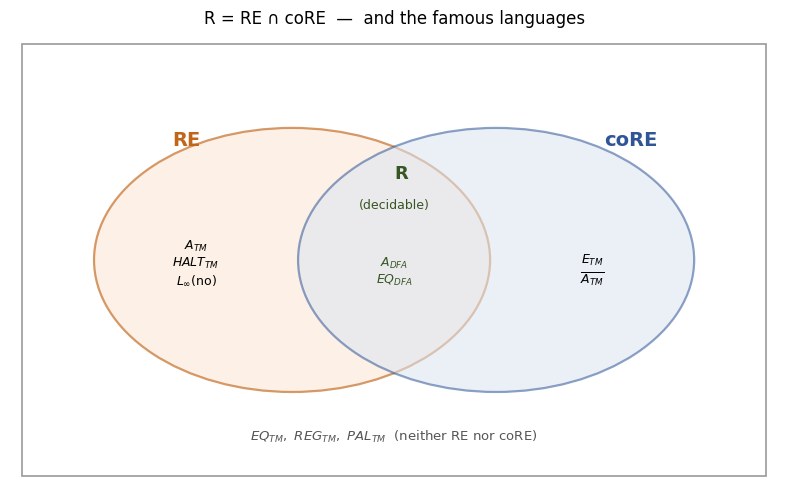

In [12]:
# R = RE ∩ coRE, drawn as a Venn diagram with where the famous languages sit.
fig, ax = plt.subplots(figsize=(8,5)); ax.set_aspect('equal'); ax.axis('off')
ax.add_patch(Rectangle((-6.2,-3.6),12.4,7.2, fill=False, edgecolor="#999", lw=1.2))
ax.add_patch(Ellipse((-1.7,0),6.6,4.4, facecolor="#fde9d9", edgecolor="#c0651a", lw=1.6, alpha=0.65))
ax.add_patch(Ellipse(( 1.7,0),6.6,4.4, facecolor="#dbe5f1", edgecolor="#2f5597", lw=1.6, alpha=0.55))
ax.text(-3.7,1.9,"RE", fontsize=14, fontweight="bold", color="#c0651a")
ax.text( 3.5,1.9,"coRE", fontsize=14, fontweight="bold", color="#2f5597")
ax.text(0,1.35,"R", fontsize=13, fontweight="bold", color="#375623")
ax.text(0,0.85,"(decidable)", fontsize=9, ha="center", color="#375623")
ax.text(-3.3,-0.4,r"$A_{TM}$"+"\n"+r"$HALT_{TM}$"+"\n"+r"$L_\infty$(no)", fontsize=9, ha="center")
ax.text( 3.3,-0.4,r"$E_{TM}$"+"\n"+r"$\overline{A_{TM}}$", fontsize=9, ha="center")
ax.text(0,-0.4,r"$A_{DFA}$"+"\n"+r"$EQ_{DFA}$", fontsize=9, ha="center", color="#375623")
ax.text(0,-3.0,r"$EQ_{TM},\ REG_{TM},\ PAL_{TM}$  (neither RE nor coRE)", fontsize=9.5, ha="center", color="#555")
ax.set_xlim(-6.4,6.4); ax.set_ylim(-3.8,3.8)
ax.set_title("R = RE ∩ coRE  —  and the famous languages", fontsize=12)
plt.tight_layout(); plt.show()


<div dir="rtl">

## 18 · רדוקציות — המנוע של אי-הכריעוּת

כדי להראות ששפה חדשה $L$ אינה כריעה, **מבצעים רדוקציה משפה ידועה כלא-כריעה אליה**. שני סוגים בקורס:

### (א) רדוקציית טיורינג (רדוקציה ע"י מכריע)
מראים: *אם $L\in R$ אז (לא-כריעה ידועה, למשל $A_{TM}$) $\in R$.* בונים מכריע לשפה הידועה שקורא למכריע משוער $M_L$ עבור $L$ כתת-שגרה. מאחר שהשפה הידועה $\notin R$, מסיקים $L\notin R$.

זוהי התבנית "$M_{A_{TM}}$ בונה ומזין את $\langle N_{M,w}\rangle$ ל-$M_L$" מהתרגול. המכונה הבנויה $N_{M,w}$ **נבנית, לא מורצת** — רק $M_L$ מכריע.

### (ב) רדוקציית מיפוי $A\le_m B$ (חזקה יותר, מועדפת)
פונקציה **ניתנת לחישוב** $f:\Sigma^*\to\Sigma^*$ עם
$$w\in A \iff f(w)\in B.$$
$f$ חייבת לעצור על כל קלט (היא רק *כותבת* קידוד; היא אף פעם לא *מריצה* את המכונות שהיא בונה).

**מסקנות מ-$A\le_m B$:**
| אם ... | אז ... |
|---|---|
| $B\in R$ | $A\in R$ |
| $B\in RE$ | $A\in RE$ |
| $B\in coRE$ | $A\in coRE$ |
| $A\notin R$ | $B\notin R$ |
| $A\notin RE$ | $B\notin RE$ |
| $A\notin coRE$ | $B\notin coRE$ |

בנוסף: $A\le_m B \iff \overline A\le_m\overline B$ (אותה $f$!).

### מתכון ל-"$B\notin RE$ וגם $B\notin coRE$"
- כדי להראות **$B\notin RE$:** מצאו $\overline{A_{TM}}\le_m B$ (שקול ל-$A_{TM}\le_m\overline B$).
- כדי להראות **$B\notin coRE$:** מצאו $A_{TM}\le_m B$ (שקול ל-$\overline{A_{TM}}\le_m\overline B$).
- הראיתם את שניהם ⇒ $B$ "כפולת-אי-כריעוּת" (לא RE ולא coRE).

</div>

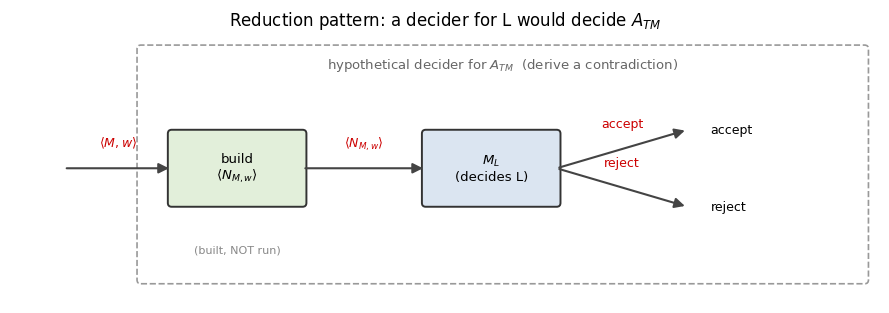

In [13]:
# Schematic of a reduction "if L in R then A_TM in R" (the decider-builds-a-machine pattern).
fig, ax = plt.subplots(figsize=(9,3.3)); ax.set_aspect('equal'); ax.axis('off')
def box(x,y,w,h,txt,fc):
    ax.add_patch(FancyBboxPatch((x,y),w,h,boxstyle="round,pad=0.05",facecolor=fc,edgecolor="#333",lw=1.4))
    ax.text(x+w/2,y+h/2,txt,ha="center",va="center",fontsize=9.5)
def arrow(x1,y1,x2,y2,lab=""):
    ax.add_patch(FancyArrowPatch((x1,y1),(x2,y2),arrowstyle="-|>",mutation_scale=15,lw=1.5,color="#444"))
    if lab: ax.text((x1+x2)/2,(y1+y2)/2+0.28,lab,ha="center",fontsize=9,color="#c00")
# outer machine box = the decider we are (wrongly) assuming exists
ax.add_patch(FancyBboxPatch((0.3,-1.4),9.4,3.0,boxstyle="round,pad=0.05",
             facecolor="none",edgecolor="#999",lw=1.2,linestyle="--"))
ax.text(5.0,1.35,r"hypothetical decider for $A_{TM}$  (derive a contradiction)",ha="center",fontsize=9.5,color="#666")
box(0.7,-0.4,1.7,0.9,"build\n"+r"$\langle N_{M,w}\rangle$","#e2efda")
box(4.0,-0.4,1.7,0.9,r"$M_L$"+"\n(decides L)","#dbe5f1")
arrow(-0.7,0.05,0.7,0.05,r"$\langle M,w\rangle$")
arrow(2.4,0.05,4.0,0.05,r"$\langle N_{M,w}\rangle$")
arrow(5.7,0.05,7.4,0.55,"accept")
arrow(5.7,0.05,7.4,-0.45,"reject")
ax.text(7.7,0.55,"accept",fontsize=9,va="center")
ax.text(7.7,-0.45,"reject",fontsize=9,va="center")
ax.text(1.55,-1.05,"(built, NOT run)",ha="center",fontsize=8,color="#888")
ax.set_xlim(-1.4,9.9); ax.set_ylim(-1.7,1.8)
ax.set_title("Reduction pattern: a decider for L would decide $A_{TM}$", fontsize=12)
plt.tight_layout(); plt.show()


<div dir="rtl">

## 19 · השפות הלא-כריעות הקלאסיות

כל אלו **לא כריעות**; הטור מציין היכן הן יושבות (מוכח דרך רדוקציות מ-$A_{TM}$ / $\overline{A_{TM}}$):

| שפה | משמעות | RE? | coRE? |
|---|---|---|---|
| $A_{TM}=\{\langle M,w\rangle: M\text{ accepts }w\}$ | קבלה | ✅ RE | ❌ |
| $HALT_{TM}=\{\langle M,w\rangle: M\text{ halts on }w\}$ | בעיית העצירה | ✅ RE | ❌ |
| $E_{TM}=\{\langle M\rangle: L(M)=\varnothing\}$ | ריקוּת | ❌ | ✅ coRE |
| $EQ_{TM}=\{\langle M_1,M_2\rangle: L(M_1)=L(M_2)\}$ | שקילות | ❌ | ❌ |
| $REG_{TM}=\{\langle M\rangle: L(M)\text{ regular}\}$ | רגולריות | ❌ | ❌ |
| $PAL_{TM}=\{\langle M\rangle: L(M)=PAL\}$ | "האם בדיוק הפלינדרומים" | ❌ | ❌ |
| $L_\infty=\{\langle M\rangle: L(M)\text{ infinite}\}$ | אינסופיוּת | ❌ | ❌ |

**רדוקציות פתורות (מהתרגולים):**
- $E_{TM}\le_m PAL_{TM}$: $f(\langle M\rangle)=\langle N\rangle$ כאשר $N$ על $x$ מקבל אם $x\in PAL$, אחרת מריץ את *המזהה של $\overline{E_{TM}}$* / $M$ ... בבחירה זהירה כך ש-$L(N)=PAL\iff L(M)=\varnothing$.
- $A_{TM}\le_m L_\infty$: $f(\langle M,w\rangle)=\langle N\rangle$, $N$ על כל $x$ מריץ את $M$ על $w$; אז $L(N)=\Sigma^*$ (אינסופית) אם $M$ מקבל $w$, אחרת $\varnothing$ (סופית).
- $\overline{A_{TM}}\le_m L_\infty$: אותו גאדג'ט אבל $N$ מקבל $x$ אם"ם $M$ **לא** מקבל $w$ בתוך $|x|$ צעדים ⇒ $L(N)=\Sigma^*$ כש-$M$ דוחה/נתקע, סופית כש-$M$ מקבל.

</div>

<div dir="rtl">

## 20 · משפט רייס — אי-כריעוּת בחינם

> **משפט רייס.** תהי $P$ **תכונה סמנטית לא-טריוויאלית** כלשהי של שפות ניתנות לזיהוי — כלומר תכונה של $L(M)$ (לא של הקוד של $M$) שיש שפה ניתנת לזיהוי שמקיימת אותה ויש כזו שלא. אז
> $$\{\langle M\rangle : L(M)\text{ has property }P\}\ \text{is undecidable.}$$

**שני תנאים לבדוק לפני שמפעילים:**
1. **סמנטית** — תלויה רק ב-$L(M)$: אם $L(M_1)=L(M_2)$ אז שתיהן או אף אחת בשפה.
2. **לא-טריוויאלית** — לפחות שפה ניתנת לזיהוי אחת מקיימת את $P$ ולפחות אחת לא (כך שזו לא $\varnothing$ ולא כל הקידודים).

**לא-כריעות מיידית לפי רייס:** $E_{TM}$, $REG_{TM}$, $PAL_{TM}$, $L_\infty$, $\{\langle M\rangle: \varepsilon\in L(M)\}$, $\{\langle M\rangle:|L(M)|=5\}$, $CFL_{TM}$, ...

⚠️ **רייס לא חל על:**
- תכונות של ה**מכונה**, לא של השפה — למשל "ל-$M$ יש 10 מצבים", "$M$ עוצרת תוך 100 צעדים", "$M$ אי-פעם זזה שמאלה" (אלו עשויות להיות כריעות).
- **$A_{TM}$, $HALT_{TM}$, $EQ_{TM}$** — אלו מקבלות $\langle M,w\rangle$ או שתי מכונות, לא $\langle M\rangle$ יחיד שמתאר תכונה אחת של שפה אחת.
- רייס נותן **אי-כריעות בלבד** — הוא לא אומר דבר על RE מול coRE. לשם כך עדיין צריך רדוקציות מיפוי מפורשות.

</div>

<div dir="rtl">

---
# 🍳 ספר מתכונים לטכניקות הוכחה (מה לעשות כשרואים...)

### "הוכח ש-$L$ רגולרית"
- בנו DFA/NFA, ביטוי רגולרי, או דקדוק רגולרי — מה שהכי קל.
- או בנו אותה משפות רגולריות ידועות דרך **סגירוּת** (∪, ∩, משלים, ·, *, היפוך, הומומורפיזם, הצבה).
- או הראו מספר סופי של מחלקות מייהיל–נרוד.

### "הוכח ש-$L$ **אינה** רגולרית"
- **למת הניפוח** (משחק יריב; בחרו $w$ כתלות ב-$n$, נפחו כדי לצאת מ-$L$).
- **סתירה דרך סגירוּת:** חתכו עם שפה רגולרית כדי לבודד שפה לא-רגולרית ידועה.
- **מייהיל–נרוד:** הציגו אינסוף מילים נבדלות זו מזו.

### "הוכח ש-$L$ חסרת הקשר"
- תנו CFG או PDA.
- סגירוּת: ∪, ·, *, היפוך, הצבה, או $\cap$ **עם שפה רגולרית**.

### "הוכח ש-$L$ **אינה** חסרת הקשר"
- **למת הניפוח לשפות חסרות הקשר** (השתמשו ב-$|vxy|\le p$ כדי ללכוד את החלקים המנופחים במעט מדי בלוקים).
- סגירוּת: אם $L\cap(\text{regular})$ או תמונה הומומורפית נותנת שפה לא-חסרת-הקשר ידועה — סתירה. (זכרו: **אין** סגירוּת תחת משלים/חיתוך לשפות חסרות הקשר.)

### "הוכח ש-$L$ כריעה (R)"
- תארו מ"ט וטענו שהיא **תמיד עוצרת**.
- בצעו רדוקציה לבעיה כריעה; השתמשו בארגז הכלים של R ($A_{DFA},E_{DFA},EQ_{DFA},A_{CFG},E_{CFG}$).

### "הוכח ש-$L$ ניתנת לזיהוי (RE)"
- בנו מזהה (עשוי להיתקע בלולאה על דחיות).
- **שזירה (dovetailing) / הרצה מפוקחת:** כדי לזהות "∃x ..." הריצו את $M$ על $x_1,x_2,\dots$ במקביל, צעד נוסף אחד בכל סבב, קבלו ברגע שאחד מצליח.

### "הוכח ש-$L$ לא כריעה / לא RE / לא coRE"
1. האם זו תכונה **סמנטית** לא-טריוויאלית של $L(M)$? → **רייס** (לא כריעה).
2. לרמת RE/coRE, בצעו **רדוקציית מיפוי**:
   - לא coRE ⇐ $A_{TM}\le_m L$;
   - לא RE ⇐ $\overline{A_{TM}}\le_m L$.
3. או **רדוקציית טיורינג** ("אם $L\in R$ אז $A_{TM}\in R$").
4. תמיד ציינו ש-$f$ **ניתנת לחישוב** והוכיחו את **שני הכיוונים** של $w\in A\iff f(w)\in B$.

</div>

<div dir="rtl">

---
# 📑 תבניות הוכחה למבחן (מותאם למבנה של שנה שעברה)

למבחן **שלושה חלקים** (אותו מבנה כמו 2025, עם שינוי אחד בחלק 3 — ראו הערה):

| חלק | בחירה | מה נבדק |
|---|---|---|
| **1** | עונים על **כל 3** | הוכחות "טרנספורמציה": בהינתן $f(L)$ הבנויה מ-$L$ ע"י פעולת מחרוזות, הוכיחו ש-$f(L)$ **רגולרית / לא רגולרית / חסרת הקשר** |
| **2** | עונים על **הכול** | **סיווג מלא R / RE / coRE** של שפת מ"ט אחת — כן/לא לכל אחת ו**להוכיח את שלושתן** |
| **3** | **בוחרים 4 מתוך 5** | מגוון: בניית **CFG**; הוכח/הפרך **חסרת הקשר ולא רגולרית**; דוגמאות נגד ל**סגירוּת**; הוכח-או-הפרך על **$\le_m$**; הוכח-או-הפרך **מ"ט/כריעוּת** |

> **📌 שינוי השנה:** בחלק 3 יש **5 שאלות ועונים על 4** (ב-2025 היו 6, בוחרים 5). חלקים 1–2 ללא שינוי. *(אַמתו את חלוקת הניקוד ביום המבחן — בשנה שעברה חלק 1 היה 3×12, חלק 2 היה 29, חלק 3 היה 7 נק' לשאלה.)*

התבניות שלמטה הן שלדי הכתיבה שהבודקים מתגמלים. מלאו את הרווחים.

## תבנית A — "אם $L$ רגולרית אז $f(L)$ רגולרית" (חלק 1)
שיטת **פירוק-למצבים + סגירוּת** (הטכניקה מהרצאה 13).

> 1. *"מאחר ש-$L$ רגולרית, קיים DFA $A=(Q,\Sigma,\delta,q_s,F)$ עם $L(A)=L$."*
> 2. הגדירו לכל $p,q\in Q$:  $L^A_{p,q}=\{w \mid \hat\delta(p,w)=q\}$ — *"כל $L^A_{p,q}$ רגולרית"* (זו $A$ עם מצב התחלתי $p$ ומצב מקבל יחיד $q$).
> 3. בטאו את כל השפה דרך המצבים: פצלו את $L$ בנקודות שהפעולה מתייחסת אליהן, למשל $L=\bigcup_{p\in Q,\,f\in F} L^A_{q_s,p}\cdot L^A_{p,f}$.
> 4. בנו את $f(L)$ מהחלקים הרגולריים בעזרת פעולות ש**השפות הרגולריות סגורות תחתן**: איחוד סופי, שרשור, חיתוך, היפוך, ו**הצבה (רגולרית) / הומומורפיזם**.
> 5. הסיקו: *"$f(L)$ היא איחוד סופי של שרשורים / חיתוכים / הצבות של שפות רגולריות, ולכן רגולרית." ∎*

**רעיון פתור (2025 שאלה 1):** עבור $f_1(L)=\{x \mid xy\bar x\bar y\in L\}$, פצלו $w=xy\bar x\bar y$ על נקודות-מצב $q_s\to p\to q\to r\to f$:
$$f_1(L)=\bigcup_{p,q,r,\,f\in F}\big(L^A_{q_s,p}\cap \mathrm{flip}(L^A_{q,r})\big)\cdot g\big(L^A_{p,q}\cap L^A_{r,f}\big).$$
עובדות-עזר שמותר לצטט:
- **flip רגולרית:** $\mathrm{flip}(L)=\{\bar w\mid w\in L\}$ רגולרית (הומומורפיזם $0\mapsto1,\ 1\mapsto0$).
- **טריק ה-$g(\cdot)$/$\varepsilon$:** כדי לאלץ שני חלקים להתלכד, חתכו אותם והציבו את התוצאה ל-$\varepsilon$ ע"י $g(0)=g(1)=\{\varepsilon\}$ — תורם $\{\varepsilon\}$ כשהחיתוך אינו ריק, ו-$\varnothing$ (מבטל את האיבר) כשהוא ריק.

## תבנית B — "קיימת $L$ רגולרית כך ש-$f(L)$ אינה רגולרית" / "הוכח ש-$f(L)$ אינה רגולרית"
שני צעדים: **(i)** בחרו $L$ רגולרית קונקרטית (לרוב $L=\{\varepsilon\}$ או $\Sigma^*$ — נמקו בשורת ביטוי רגולרי אחת), ואז **(ii)** למת הניפוח על $f(L)$ המתקבלת.

> *"תהי $L=\{\varepsilon\}$ (רגולרית, ע"י $r=\varepsilon$). אז $f(L)=\{\,\_\_\_\,\}$."*
> 1. נניח $f(L)$ רגולרית ⇒ אורך ניפוח $n$.
> 2. בחרו $w=\_\_\_\in f(L)$, $|w|\ge n$ (למשל $0^n1^n$).
> 3. כל פיצול $w=xyz$ עם $|y|>0,|xy|\le n$ ⇒ $y=0^t$ ($t>0$) בבלוק הראשון.
> 4. נפחו $i=\_\_$: $w_i=\_\_\_\notin f(L)$ כי $\_\_\_$. סתירה. ∎

## תבנית C — "אם $L$ רגולרית אז $f(L)$ חסרת הקשר" (חלק 1)
בנו **PDA מתוך ה-DFA** — המחסנית מתאימה חלק הפוך/נספר. התבנית של הבודק ב-2025:

> *"מאחר ש-$L$ רגולרית קיים DFA $A=(Q,\Sigma,\delta,q_{s_A},F_A)$ עם $L(A)=L$. נבנה PDA $D=(Q_P,\Sigma,\Gamma,\delta_P,q_{s_P},F_P)$:"*
> - **שני שלבים:** $Q_P=Q\times\{1,2\}\cup\{\dots\}$ — שלב 1 קורא ודוחף את החלק הראשון, שלב 2 שולף כדי להתאים.
> - לכל מעבר $\delta_A(p,\sigma)=q$ הוסיפו את מהלך הדחיפה בשלב 1 ואת מהלך השליפה/השוואה בשלב 2 (הפעילו flip/היפוך לפי הצורך).
> - הוסיפו מהלכי-$\varepsilon$ למעבר בין השלבים במצב מקבל ולרוקן את המחסנית בסוף; קבעו $F_P=\{f\}$.

(אם CFG קל יותר מ-PDA, תנו את הדקדוק במקום — שניהם מתקבלים.)

## תבנית D — "הוכח ש-$L$ חסרת הקשר ע"י בניית CFG" (חלק 3)
תנו את הדקדוק **באופן פורמלי** והסבירו בקצרה למה הוא יוצר את $L$.

> *"$G=(V,\Sigma,S,R)$ עם $V=\{\dots\}$, $\Sigma=\{\dots\}$, וכללים $S\to\dots$, $A\to\dots$"*

**פתור (2025):** $L=\{a^m b a^n b\mid m\ge 2n\}$:  $S\to Ab,\quad A\to aaAa \mid aA \mid b.$  (ה-$aa\dots a$ סביב הרקורסיה אוכף $m\ge 2n$.)

</div>

<div dir="rtl">

## תבנית E — סיווג מלא R / RE / coRE (חלק 2, שאלת ה-29 נק')

נתונה שפת מ"ט $L$. **קבעו קודם את שלוש התשובות**, ואז הוכיחו כל אחת. התבנית כמעט תמיד אחת מ:
- $L\in RE\setminus R$ → הוכיחו **$L\in RE$** (מזהה) **וגם** **$L\notin R$** (רדוקציה).
- $L\in coRE\setminus R$ → הוכיחו $\overline L\in RE$ ו-$L\notin R$.
- $L$ לא RE ולא coRE → הוכיחו **$L\notin RE$** וגם **$L\notin coRE$** (שתי רדוקציות).

**איך בוחרים:** קראו את הכמת. **"∃ עד שניתן לאמת ע"י הרצה לזמן סופי"** ("∃x כך ש-$M$ מקבל את $x$…") בד"כ **RE**. "∀x…" או "$L(M)=$ משהו" בד"כ **לא** RE. מתכון: **לא coRE ⇐ $A_{TM}\le_m L$;  לא RE ⇐ $\overline{A_{TM}}\le_m L$** (≡ $A_{TM}\le_m\overline L$).

### E1 — הראו $L\in RE$ (מזהה, לרוב ע"י **שזירה / dovetailing**)
שייכות מסוג "∃x…" לא יכולה לנסות $x$ אחד (עלול להיתקע). הריצו את **כל** ה-$x$ במקביל, קצת יותר בכל סבב:

> $M_L=$ "על קלט $\langle M\rangle$:  עבור $i=0,1,2,\dots$:  עבור $j=0$ עד $i$:  לכל $x\in\Sigma^{j}$ (סדר לקסיקוגרפי): הריצו $M$ על $x$ ל-$i$ צעדים; אם מקבל, הריצו $M$ על $x^R$ ל-$i$ צעדים; אם זה **דוחה**, *קבל*."

נכונות (טיעון ה-**$k$ המינימלי**):
- *$\langle M\rangle\in L$:* קיים עד $x$; קחו את זה שממזער את $k=\max(k_x,k_{x^R})$ (וראשון לקסיקוגרפית בתיקו). עד סבב $i=k$, $M_L$ סימל מספיק כדי לראותו ⇒ **מקבל**.
- *$\langle M\rangle\notin L$:* אין עד, ולכן שורת הקבלה לעולם לא מגיעה ⇒ $M_L$ לעולם לא מקבל (עלול להיתקע — מותר ל-RE). ∎

### E2 — הראו $L\notin R$ / $\notin coRE$ / $\notin RE$ (רדוקציית מיפוי)
השתמשו ב**תבנית F**: ל**לא coRE** תנו $A_{TM}\le_m L$; ל**לא RE** תנו $\overline{A_{TM}}\le_m L$. מאחר ש-$A_{TM}\notin coRE$ ו-$\overline{A_{TM}}\notin RE$, הקושי עובר.

## תבנית F — רדוקציית מיפוי $A\le_m B$ (השלד האוניברסלי)
> *"נציג $f$ ניתנת לחישוב עם $w\in A\iff f(w)\in B$."*
> $$f(\langle M,w\rangle)=\langle N_{M,w}\rangle,\qquad N_{M,w}=\text{"על קלט }x:\ \_\_\_\_\text{"}$$
> **נכונות — תמיד שלוש נקודות:**
> - **$f$ ניתנת לחישוב:** היא רק *כותבת את הקידוד* של $N_{M,w}$ (מקודדת בתוכה $M,w$); היא לא מריצה את $N$. סופי ⇒ עוצר.
> - **($\Rightarrow$)** אם $\langle M,w\rangle\in A$ אז $L(N_{M,w})=\_\_\_$, ולכן $f(\cdot)\in B$.
> - **($\Leftarrow$)** אם $\langle M,w\rangle\notin A$ אז $L(N_{M,w})=\_\_\_$, ולכן $f(\cdot)\notin B$.

**שני הגאדג'טים השימושיים** (תרגולים + פתרון 2025):
- *להחליף את $L(N)$ בין $\Sigma^*$ ל-$\varnothing$:* $N$ על $x$ מריץ את $M$ על $w$ ועושה כמוהו ⇒ $L(N)=\Sigma^*$ אם $M$ מקבל $w$, אחרת $\varnothing$.
- *להחליף בין שפה קבועה ל-$\varnothing/\Sigma^*$:* $N$ על $x$ מקבל אם"ם ($x\in$ שפה-קבועה) וגם/או ($M$ מקבל $w$) — בחרו את הצירוף שנותן את השקילות.

</div>

<div dir="rtl">

## תבנית G — "הוכח או הפרך" על $\le_m$ או סגירוּת (חלק 3)
בד"כ **שקריות**, ונענות ב**דוגמה נגדית** משפות ידועות. החזיקו מוכנות:
- **כל שפה ב-R ניתנת לרדוקציה לכל שפה לא-טריוויאלית:** אם $A\in R$ ו-$B$ לא-טריוויאלית אז $A\le_m B$ (הכריעו $A$, פלטו מופע קבוע של כן/לא ב-$B$).
- **אם $A\le_m C$ ו-$C\in R$ אז $A\in R$** — הניגוד הורג טענות "בהכרח $A\le_m C$" ע"י $A=A_{TM}\notin R$.
- **שפות חסרות הקשר: לא סגורות תחת $\cap$ או משלים**, אבל סגורות תחת $\cap$ עם שפה רגולרית ותחת איחוד. מנוע דוגמאות-נגד: בחרו $L_1,L_2$ שהחיתוך-עם-רגולרית שלהן מבודד את $\{a^nb^nc^n\}$.

> *הפרכת "בהכרח $A\le_m C$":* "שקר. קחו $A=A_{TM}$, ו-$B,C$ שפות $R$ לא-טריוויאליות $\_\_\_$. אז $A\cup B\le_m C$ כי $\_\_\_$, אבל $A\not\le_m C$ כי $A\notin R$ בעוד $C\in R$." ∎

## תבנית H — כריעוּת של מכונת "סימולציה חסומה" (חלק 3)
כש-$N$ **מריצה את $M$ למספר צעדים חסום ע"י הקלט** ("$|x|$ צעדים"), השפה שלה בד"כ **כריעה** — הסימולציה סופית.

> *"$L(N_M)=\{\langle x,y\rangle \mid M$ מקבל את $y$ תוך $|x|$ צעדים לכל היותר$\}\in R$. המכריע הוא $N_M$ עם הענף הלא-עוצר משונה ל**דחייה**: סמלו $M$ על $y$ ל-$|x|$ צעדים (סופי), קבלו אם"ם קיבל, אחרת דחו."* ∎

זה הורג שאלות "הוכח/הפרך $L(N_M)\in coRE\setminus R$": סימולציה חסומה היא ב-$R$, ולכן **לא יכולה** להיות ב-$coRE\setminus R$.

---
### 🎯 תוכנית ליום המבחן לפי חלקים
- **חלק 1 (חובה):** A / B / C. פתחו ב-"מאחר ש-$L$ רגולרית קיים DFA…" ופרקו דרך $L^A_{p,q}$.
- **חלק 2 (חובה):** קבעו את 3 התשובות, ואז E1 (מזהה + $k$ מינימלי) ו-E2/F (רדוקציית מיפוי אחת או שתיים). תמיד כללו את **3 נקודות הנכונות**.
- **חלק 3 (בחרו 4 מתוך 5):** עשו קודם את בניית ה-CFG (D) ואת הסימולציה-החסומה / $\le_m$ הוכח-או-הפרך (G, H) — המהירים ביותר. דלגו על זה שאתם הכי פחות בטוחים בו.

</div>

<div dir="rtl">

---
# ⚠️ מלכודות המבחן הנפוצות (לזכור בעל-פה)

1. **משלים דורש DFA מלא.** אי אפשר לבצע משלים ל-NFA ע"י החלפת מצבים מקבלים. דטרמיניזציה קודם.
2. **$\varnothing^*=\{\varepsilon\}$**, $\varnothing\cdot A=\varnothing$, $A^0=\{\varepsilon\}$. לא לאבד/להוסיף $\varepsilon$.
3. **למת הניפוח מוכיחה רק אי-רגולריות/אי-חוסר-הקשר** — לעולם אל תשתמשו בה כדי להוכיח ששפה *כן* רגולרית. ו*אתם* בוחרים את $w$ ואת $i$; *היריב* בוחר את $n/p$ ואת הפיצול.
4. **שפות חסרות הקשר אינן סגורות תחת חיתוך או משלים** — אבל **כן** סגורות תחת חיתוך עם שפה *רגולרית*.
5. **DPDA ⊊ PDA** — אי-דטרמיניזם באמת מוסיף כוח ל-PDA (בניגוד לאוטומטים סופיים, שבהם NFA = DFA).
6. **$EQ_{DFA}$ כריעה, $EQ_{CFG}$ לא כריעה.** אל תניחו שבעיות CFG מתנהגות כמו בעיות DFA.
7. **מזהה ≠ מכריע.** מכריע חייב לעצור על *כל* קלט. "הרץ את $M$ על $w$ ועשה כמוהו" זה *מזהה*, לא מכריע.
8. **ברדוקציות, בונים מכונות — לא מריצים אותן.** הרדוקציה $f$ חייבת לעצור; היא כותבת את $\langle N\rangle$, היא לא מדמה את $N$.
9. **משפט רייס עוסק בשפה $L(M)$, לא בקוד $M$,** ונותן *אי-כריעות* בלבד — לא את הסיווג RE/coRE.
10. **$R = RE \cap coRE$.** כדי להראות "לא RE", רדוקציה מ-$\overline{A_{TM}}$ (או $A_{TM}\le_m\overline L$); כדי להראות "לא coRE", רדוקציה מ-$A_{TM}$.
11. **כיוון $\le_m$ חשוב.** $A\le_m B$ דוחף *כריעוּת כלפי מטה* (מ-$B$ ל-$A$) ו*קושי כלפי מעלה* (מ-$A$ ל-$B$).

</div>

<div dir="rtl">

---
# 📋 דף עזר מהיר

### מכונה ↔ מחלקת שפה
| מכונה | מזהה |
|---|---|
| DFA = NFA = ביטוי רגולרי = RG | רגולרית |
| PDA (אי-דטרמיניסטי) | חסרת הקשר |
| DPDA | חסרת הקשר דטרמיניסטית (תת-קבוצה ממש) |
| מ"ט שעוצרת תמיד | כריעה (R) |
| מ"ט (כללית) | ניתנת לזיהוי (RE) |

### דף עזר לסגירוּת (✅ סגורה / ❌ לא)
| | ∪ | ∩ | משלים | · | * | ∩ רגולרית |
|---|---|---|---|---|---|---|
| רגולרית | ✅ | ✅ | ✅ | ✅ | ✅ | ✅ |
| חסרת הקשר | ✅ | ❌ | ❌ | ✅ | ✅ | ✅ |
| R | ✅ | ✅ | ✅ | ✅ | ✅ | ✅ |
| RE | ✅ | ✅ | ❌ | ✅ | ✅ | ✅ |

### כריעה מול לא (בעיות על מ"ט יחידה)
| כריעה | לא כריעה |
|---|---|
| $A_{DFA}, A_{NFA}, A_{REX}, A_{CFG}$ | $A_{TM}, HALT_{TM}$ |
| $E_{DFA}, E_{CFG}$ | $E_{TM}, EQ_{TM}, REG_{TM}, L_\infty, PAL_{TM}$ |
| $EQ_{DFA}$ | $EQ_{CFG}, ALL_{CFG}$ |

### המרות שחובה לדעת לבצע ביד
NFA→DFA (קבוצת חזקה) · ביטוי רגולרי→NFA (תומפסון) · NFA→ביטוי רגולרי (סילוק GNFA) · NFA↔RG · CFG→CNF · CFG→PDA · PDA→CFG · מינימיזציה של DFA.

---
### ✅ אתם תסתדרו. תישנו לפני המבחן. בהצלחה! 🍀

</div>

In [14]:
# Quick self-check: classify a few languages (regular / CFL / decidable-not-CF / undecidable)
classify = {
    "{0^n 1^n}":                 "CFL, not regular",
    "{0^n 1^n 2^n}":             "decidable, not CFL",
    "{ww : w in Sigma*}":        "decidable, not CFL",
    "{w : #0(w) = #1(w)}":       "CFL, not regular",
    "{w : w has even # of 1s}":  "regular",
    "A_TM":                      "RE, not decidable",
    "complement of A_TM":        "not even RE",
    "E_TM":                      "coRE, not decidable (Rice)",
}
for lang, ans in classify.items():
    print(f"{lang:30} -> {ans}")


{0^n 1^n}                      -> CFL, not regular
{0^n 1^n 2^n}                  -> decidable, not CFL
{ww : w in Sigma*}             -> decidable, not CFL
{w : #0(w) = #1(w)}            -> CFL, not regular
{w : w has even # of 1s}       -> regular
A_TM                           -> RE, not decidable
complement of A_TM             -> not even RE
E_TM                           -> coRE, not decidable (Rice)
